In [ ]:
import os
import re

# ── Step 1: Find or clone decagon ────────────────────────
def find_main_py():
    search_paths = [
        '/content/decagon/decagon/decagon',
        '/content/decagon/decagon',
        '/content/decagon',
        '/content',
    ]
    for path in search_paths:
        if os.path.exists(f'{path}/main.py'):
            return path
    return None

decagon_path = find_main_py()

if decagon_path:
    print(f"Found existing decagon at: {decagon_path}")
    os.chdir(decagon_path)
else:
    print("Cloning fresh copy...")
    os.chdir('/content')
    os.system('rm -rf decagon_fresh')
    os.system('git clone https://github.com/mims-harvard/decagon.git decagon_fresh')
    os.chdir('/content/decagon_fresh')
    decagon_path = '/content/decagon_fresh'

print(f"Working directory: {os.getcwd()}")
print(f"Files: {os.listdir('.')}")

# ── Step 2: Install packages ──────────────────────────────
os.system('pip install networkx==2.6.3 scikit-learn imbalanced-learn shap -q')
print("Packages installed!")

# ── Step 3: Apply ALL TF2 fixes ──────────────────────────
files_to_fix = [
    'main.py',
    'decagon/deep/layers.py',
    'decagon/deep/model.py',
    'decagon/deep/optimizer.py',
    'decagon/deep/inits.py',
    'decagon/deep/minibatch.py',
    'decagon/utility/preprocessing.py',
]

replacements = [
    ('import tensorflow as tf',
     'import tensorflow.compat.v1 as tf\ntf.disable_v2_behavior()'),
    ('tf.app.flags',                    'tf.compat.v1.app.flags'),
    ('tf.op_scope',                     'tf.compat.v1.op_scope'),
    ('tf.get_collection',               'tf.compat.v1.get_collection'),
    ('tf.GraphKeys',                    'tf.compat.v1.GraphKeys'),
    ('tf.placeholder_with_default',     'tf.compat.v1.placeholder_with_default'),
    ('tf.sparse_placeholder',           'tf.compat.v1.sparse_placeholder'),
    ('tf.placeholder',                  'tf.compat.v1.placeholder'),
    ('tf.variable_scope',               'tf.compat.v1.variable_scope'),
    ('tf.get_variable',                 'tf.compat.v1.get_variable'),
    ('tf.global_variables_initializer', 'tf.compat.v1.global_variables_initializer'),
    ('tf.local_variables_initializer',  'tf.compat.v1.local_variables_initializer'),
    ('tf.zeros_initializer',            'tf.compat.v1.zeros_initializer'),
    ('tf.Variable',                     'tf.compat.v1.Variable'),
    ('tf.assign',                       'tf.compat.v1.assign'),
    ('tf.Session',                      'tf.compat.v1.Session'),
    ('tf.train.AdamOptimizer',          'tf.compat.v1.train.AdamOptimizer'),
    ('tf.train.Saver',                  'tf.compat.v1.train.Saver'),
    ('tf.train.',                       'tf.compat.v1.train.'),
    ('tf.nn.l2_normalize',              'tf.compat.v1.nn.l2_normalize'),
    ('tf.nn.dropout',                   'tf.compat.v1.nn.dropout'),
    ('tf.nn.sigmoid',                   'tf.compat.v1.nn.sigmoid'),
    ('tf.nn.relu',                      'tf.compat.v1.nn.relu'),
    ('tf.nn.',                          'tf.compat.v1.nn.'),
    ('tf.sparse_tensor_dense_matmul',   'tf.sparse.sparse_dense_matmul'),
    ('tf.sparse_retain',                'tf.sparse.retain'),
    ('tf.sparse_add',                   'tf.sparse.add'),
    ('tf.SparseTensor',                 'tf.compat.v1.SparseTensor'),
    ('tf.random_uniform',               'tf.compat.v1.random_uniform'),
    ('tf.random_normal',                'tf.compat.v1.random_normal'),
    ('tf.truncated_normal',             'tf.compat.v1.truncated_normal'),
    ('tf.diag_part',                    'tf.linalg.diag_part'),
    ('tf.diag',                         'tf.linalg.diag'),
    ('tf.matmul',                       'tf.compat.v1.matmul'),
    ('tf.reduce_mean',                  'tf.compat.v1.reduce_mean'),
    ('tf.reduce_sum',                   'tf.compat.v1.reduce_sum'),
    ('tf.cast',                         'tf.compat.v1.cast'),
    ('tf.sqrt',                         'tf.compat.v1.sqrt'),
    ('tf.log',                          'tf.compat.v1.log'),
    ('tf.exp',                          'tf.compat.v1.exp'),
    ('tf.sigmoid',                      'tf.compat.v1.sigmoid'),
    ('tf.shape',                        'tf.compat.v1.shape'),
    ('tf.reshape',                      'tf.compat.v1.reshape'),
    ('tf.transpose',                    'tf.compat.v1.transpose'),
    ('tf.expand_dims',                  'tf.compat.v1.expand_dims'),
    ('tf.squeeze',                      'tf.compat.v1.squeeze'),
    ('tf.concat',                       'tf.compat.v1.concat'),
    ('tf.zeros',                        'tf.compat.v1.zeros'),
    ('tf.ones',                         'tf.compat.v1.ones'),
    ('tf.constant',                     'tf.compat.v1.constant'),
    ('tf.name_scope',                   'tf.compat.v1.name_scope'),
    ('tf.losses.',                      'tf.compat.v1.losses.'),
    ('tf.summary.',                     'tf.compat.v1.summary.'),
    ('tf.layers.',                      'tf.compat.v1.layers.'),
    ('tf.add_n',                        'tf.compat.v1.add_n'),
    ('tf.where',                        'tf.compat.v1.where'),
    ('tf.boolean_mask',                 'tf.compat.v1.boolean_mask'),
    ('tf.floor',                        'tf.compat.v1.floor'),
    ('tf.fill',                         'tf.compat.v1.fill'),
    ('tf.eye',                          'tf.compat.v1.eye'),
]

for filepath in files_to_fix:
    if not os.path.exists(filepath):
        continue
    with open(filepath, 'r') as f:
        content = f.read()
    original = content
    for old, new in replacements:
        content = content.replace(old, new)
    content = re.sub(
        r'tf\.compat\.v1\.compat\.v1', 'tf.compat.v1', content
    )
    if content != original:
        with open(filepath, 'w') as f:
            f.write(content)
        print(f"Fixed: {filepath}")

# ── Step 4: Apply optimizer fix ───────────────────────────
with open('decagon/deep/optimizer.py', 'r') as f:
    content = f.read()

old_opt = '''        labels = tf.compat.v1.reshape(tf.compat.v1.cast(self.row_inputs, dtype=tf.int64), [self.batch_size, 1])
        neg_samples_list = []
        for i, j in self.edge_types:
            for k in range(self.edge_types[i,j]):
                neg_samples, _, _ = tf.compat.v1.nn.fixed_unigram_candidate_sampler(
                    true_classes=labels,
                    num_true=1,
                    num_sampled=self.batch_size,
                    unique=False,
                    range_max=len(self.degrees[i][k]),
                    distortion=0.75,
                    unigrams=self.degrees[i][k].tolist())
                neg_samples_list.append(neg_samples)'''

new_opt = '''        neg_samples_list = []
        for i, j in self.edge_types:
            for k in range(self.edge_types[i,j]):
                range_max = len(self.degrees[i][k])
                clipped = tf.compat.v1.clip_by_value(
                    tf.compat.v1.cast(self.row_inputs, dtype=tf.int64),
                    0, range_max - 1)
                labels = tf.compat.v1.reshape(
                    clipped, [self.batch_size, 1])
                neg_samples, _, _ = tf.compat.v1.nn.fixed_unigram_candidate_sampler(
                    true_classes=labels,
                    num_true=1,
                    num_sampled=self.batch_size,
                    unique=False,
                    range_max=range_max,
                    distortion=0.75,
                    unigrams=self.degrees[i][k].tolist())
                neg_samples_list.append(neg_samples)'''

if old_opt in content:
    content = content.replace(old_opt, new_opt)
    with open('decagon/deep/optimizer.py', 'w') as f:
        f.write(content)
    print("Optimizer fix applied!")
elif 'clip_by_value' in content:
    print("Optimizer fix already there!")
else:
    print("WARNING: Could not find optimizer pattern!")

# ── Step 5: Verify ────────────────────────────────────────
print("\n" + "="*50)
print("SETUP COMPLETE")
print("="*50)
print(f"Directory:       {os.getcwd()}")
print(f"main.py exists:  {os.path.exists('main.py')}")
print(f"Optimizer fixed: {'clip_by_value' in open('decagon/deep/optimizer.py').read()}")
print(f"GPU available:   ", end="")
import tensorflow as tf
print("Yes!" if tf.test.is_gpu_available() else "No — check runtime type")

Cloning fresh copy...
Working directory: /content/decagon_fresh
Files: ['.git', '.gitignore', 'images', 'README.md', 'main.py', 'polypharmacy', 'decagon', 'requirements.txt', 'LICENSE']
Packages installed!
Fixed: main.py
Fixed: decagon/deep/layers.py
Fixed: decagon/deep/model.py
Fixed: decagon/deep/optimizer.py
Fixed: decagon/deep/inits.py
Optimizer fix applied!

SETUP COMPLETE
Directory:       /content/decagon_fresh
main.py exists:  True
Optimizer fixed: True
GPU available:   

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Yes!


In [ ]:
import os

os.makedirs('/content/data', exist_ok=True)

files = [
    'bio-decagon-combo.tar.gz',
    'bio-decagon-mono.tar.gz',
    'bio-decagon-targets.tar.gz',
    'bio-decagon-ppi.tar.gz'
]

base_url = 'http://snap.stanford.edu/decagon'

for f in files:
    out = f'/content/data/{f}'
    if not os.path.exists(out.replace('.tar.gz', '.csv')):
        print(f"Downloading {f}...")
        os.system(f'wget -q {base_url}/{f} -O {out}')
        os.system(f'tar -xzf {out} -C /content/data/')
        print(f"Done: {f}")
    else:
        print(f"Already exists: {f}")

print("\nFiles in data folder:")
print([f for f in os.listdir('/content/data') if f.endswith('.csv')])

Done: bio-decagon-combo.tar.gz
Done: bio-decagon-mono.tar.gz
Done: bio-decagon-targets.tar.gz
Done: bio-decagon-ppi.tar.gz

Files in data folder:
['._bio-decagon-mono.csv', 'bio-decagon-combo.csv', '._bio-decagon-targets.csv', '._bio-decagon-ppi.csv', '._bio-decagon-combo.csv', 'bio-decagon-ppi.csv', 'bio-decagon-targets.csv', 'bio-decagon-mono.csv']


In [ ]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTETomek
from collections import defaultdict, Counter

print("Loading real dataset...")
combo   = pd.read_csv('/content/data/bio-decagon-combo.csv')
mono    = pd.read_csv('/content/data/bio-decagon-mono.csv')
targets = pd.read_csv('/content/data/bio-decagon-targets.csv')
ppi     = pd.read_csv('/content/data/bio-decagon-ppi.csv')

drug1_col   = 'STITCH 1'
drug2_col   = 'STITCH 2'
se_col      = 'Polypharmacy Side Effect'
se_name_col = 'Side Effect Name'

se_counts      = combo[se_col].value_counts()
valid_se       = se_counts[se_counts >= 500].index
combo_filtered = combo[combo[se_col].isin(valid_se)].copy()

# ── Mixed dataset: 25 common + 25 rare ───────────────────
top25_common = se_counts[se_counts >= 500].head(25).index
top25_rare   = se_counts[se_counts >= 500].tail(25).index
mixed_se     = top25_common.tolist() + top25_rare.tolist()

combo_mixed = combo_filtered[
    combo_filtered[se_col].isin(mixed_se)
].copy()

print(f"Total side effects available: {len(valid_se)}")
print(f"Using mixed dataset: 25 common + 25 rare = 50 total")
print(f"Total triples: {len(combo_mixed):,}")

print(f"\nTop 5 COMMON side effects:")
for se in top25_common[:5]:
    name  = combo[combo[se_col]==se][se_name_col].iloc[0]
    count = se_counts[se]
    print(f"  {name:<40} {count:,} pairs")

print(f"\nBottom 5 RARE side effects:")
for se in top25_rare[-5:]:
    name  = combo[combo[se_col]==se][se_name_col].iloc[0]
    count = se_counts[se]
    print(f"  {name:<40} {count:,} pairs")

Loading real dataset...
Total side effects available: 963
Using mixed dataset: 25 common + 25 rare = 50 total
Total triples: 566,602

Top 5 COMMON side effects:
  arterial pressure NOS decreased          28,568 pairs
  anaemia                                  27,006 pairs
  Difficulty breathing                     26,037 pairs
  nausea                                   25,190 pairs
  neumonia                                 24,430 pairs

Bottom 5 RARE side effects:
  coccydynia                               508 pairs
  neonatal respiratory distress syndrome   507 pairs
  impetigo                                 507 pairs
  Collagen disease                         504 pairs
  sarcoma                                  502 pairs


In [ ]:
# Get all drugs in mixed subset
all_drugs = pd.concat([
    combo_mixed[drug1_col],
    combo_mixed[drug2_col]
]).unique()
drug2idx = {d: i for i, d in enumerate(all_drugs)}
n_drugs  = len(drug2idx)

# Side effect mappings
all_se  = mixed_se
se2idx  = {s: i for i, s in enumerate(all_se)}
n_se    = len(all_se)

# Protein mappings
all_proteins = pd.concat([
    ppi['Gene 1'], ppi['Gene 2']
]).unique()
prot2idx   = {p: i for i, p in enumerate(all_proteins)}
n_proteins = len(prot2idx)

print(f"Drugs in mixed subset: {n_drugs}")
print(f"Side effects: {n_se} (25 common + 25 rare)")
print(f"Proteins: {n_proteins:,}")

Drugs in mixed subset: 645
Side effects: 50 (25 common + 25 rare)
Proteins: 19,081


In [ ]:
# ── PPI matrix ──────────────────────────────────────────
print("Building PPI matrix...")
ppi_rows = [prot2idx[g] for g in ppi['Gene 1'] if g in prot2idx]
ppi_cols = [prot2idx[g] for g in ppi['Gene 2'] if g in prot2idx]

ppi_adj = sp.csr_matrix(
    ([1.0]*len(ppi_rows), (ppi_rows, ppi_cols)),
    shape=(n_proteins, n_proteins)
)
ppi_adj = ppi_adj + ppi_adj.T
ppi_adj[ppi_adj > 1] = 1
print(f"PPI matrix: {ppi_adj.shape}, {ppi_adj.nnz:,} edges")

# ── Drug-protein matrix ──────────────────────────────────
print("Building drug-protein matrix...")
tgt_rows = []
tgt_cols = []
for _, row in targets.iterrows():
    if row['STITCH'] in drug2idx and row['Gene'] in prot2idx:
        tgt_rows.append(drug2idx[row['STITCH']])
        tgt_cols.append(prot2idx[row['Gene']])

drug_prot_adj = sp.csr_matrix(
    ([1.0]*len(tgt_rows), (tgt_rows, tgt_cols)),
    shape=(n_drugs, n_proteins)
)
print(f"Drug-protein matrix: {drug_prot_adj.shape}, "
      f"{drug_prot_adj.nnz:,} links")

# ── Drug-drug matrices ───────────────────────────────────
print("\nBuilding drug-drug matrices...")
drug_drug_adj_list = []
se_names_list      = []

for se_code in all_se:
    se_pairs = combo_mixed[
        combo_mixed[se_col] == se_code
    ][[drug1_col, drug2_col]]

    rows = [drug2idx[d] for d in se_pairs[drug1_col]
            if d in drug2idx]
    cols = [drug2idx[d] for d in se_pairs[drug2_col]
            if d in drug2idx]

    mat = sp.csr_matrix(
        ([1.0]*len(rows), (rows, cols)),
        shape=(n_drugs, n_drugs)
    )
    mat = mat + mat.T
    mat[mat > 1] = 1
    drug_drug_adj_list.append(mat)

    name = combo[combo[se_col]==se_code][se_name_col].iloc[0]
    se_names_list.append(name)

print(f"Common side effects (first 25):")
for i in range(25):
    print(f"  {se_names_list[i]:<40} "
          f"{drug_drug_adj_list[i].nnz//2:,} pairs")

print(f"\nRare side effects (last 25):")
for i in range(25, 50):
    print(f"  {se_names_list[i]:<40} "
          f"{drug_drug_adj_list[i].nnz//2:,} pairs")

print(f"\nTotal matrices built: {len(drug_drug_adj_list)}")

Building PPI matrix...
PPI matrix: (19081, 19081), 1,431,224 edges
Building drug-protein matrix...
Drug-protein matrix: (645, 19081), 18,596 links

Building drug-drug matrices...
Common side effects (first 25):
  arterial pressure NOS decreased          28,568 pairs
  anaemia                                  27,006 pairs
  Difficulty breathing                     26,037 pairs
  nausea                                   25,190 pairs
  neumonia                                 24,430 pairs
  Fatigue                                  24,260 pairs
  Pain                                     23,894 pairs
  diarrhea                                 23,848 pairs
  asthenia                                 23,515 pairs
  emesis                                   23,043 pairs
  edema extremities                        21,981 pairs
  body temperature increased               21,806 pairs
  pleural pain                             21,781 pairs
  abdominal pain                           21,410 pairs
  Hyp

In [ ]:
# Build drug features for SMOTE
print("Building drug features for SMOTE...")
drug_prot_dense = drug_prot_adj.toarray()
pca             = PCA(n_components=50, random_state=42)
drug_features   = pca.fit_transform(drug_prot_dense)
print(f"Drug features: {drug_features.shape}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.1%}")

def build_pair_features(d1_ids, d2_ids, feats):
    f1 = feats[d1_ids]
    f2 = feats[d2_ids]
    return np.hstack([f1, f2, f1*f2])

# Apply SMOTE to side effects with < 5000 pairs
SMOTE_THRESHOLD   = 5000
balanced_adj_list = []

print(f"\nApplying SMOTETomek to side effects "
      f"with < {SMOTE_THRESHOLD} pairs...")
print("="*65)

for i, (mat, se_code, se_name) in enumerate(
    zip(drug_drug_adj_list, all_se, se_names_list)
):
    n_pairs = mat.nnz // 2

    if n_pairs < SMOTE_THRESHOLD:
        # Get positive pairs from upper triangle
        rows, cols = mat.nonzero()
        pos_mask   = rows < cols
        pos_rows   = rows[pos_mask]
        pos_cols   = cols[pos_mask]

        # Build features
        X_pos = build_pair_features(
            pos_rows, pos_cols, drug_features
        )
        y_pos = np.ones(len(X_pos))

        # Sample 3x negatives
        pos_set   = set(zip(pos_rows.tolist(),
                            pos_cols.tolist()))
        neg_pairs = []
        attempts  = 0
        n_neg     = len(X_pos) * 3

        np.random.seed(42 + i)
        while len(neg_pairs) < n_neg and \
              attempts < n_neg * 20:
            r = np.random.randint(0, n_drugs)
            c = np.random.randint(0, n_drugs)
            if r < c and (r, c) not in pos_set:
                neg_pairs.append((r, c))
            attempts += 1

        if len(neg_pairs) == 0:
            print(f"  {se_name:<40} "
                  f"no negatives found — skipping")
            balanced_adj_list.append(mat)
            continue

        neg_pairs = np.array(neg_pairs)
        X_neg     = build_pair_features(
            neg_pairs[:,0], neg_pairs[:,1], drug_features
        )
        y_neg = np.zeros(len(X_neg))

        X = np.vstack([X_pos, X_neg])
        y = np.concatenate([y_pos, y_neg])

        # Apply SMOTETomek
        try:
            scaler       = StandardScaler()
            X_scaled     = scaler.fit_transform(X)
            smote        = SMOTETomek(random_state=42)
            X_res, y_res = smote.fit_resample(X_scaled, y)

            n_new_pos   = int((y_res == 1).sum())
            n_synthetic = n_new_pos - len(X_pos)

            # Add synthetic pairs to adjacency matrix
            new_rows = list(pos_rows)
            new_cols = list(pos_cols)

            if n_synthetic > 0:
                added = 0
                r_try = 0
                np.random.seed(99 + i)
                while added < n_synthetic and \
                      r_try < n_synthetic * 20:
                    r = np.random.randint(0, n_drugs)
                    c = np.random.randint(0, n_drugs)
                    if r < c and (r, c) not in pos_set:
                        new_rows.append(r)
                        new_cols.append(c)
                        pos_set.add((r, c))
                        added += 1
                    r_try += 1

            new_mat = sp.csr_matrix(
                ([1.0]*len(new_rows), (new_rows, new_cols)),
                shape=(n_drugs, n_drugs)
            )
            new_mat = new_mat + new_mat.T
            new_mat[new_mat > 1] = 1
            balanced_adj_list.append(new_mat)

            print(f"  {se_name:<40} "
                  f"{n_pairs:>6} → {new_mat.nnz//2:>6} pairs "
                  f"(+{new_mat.nnz//2 - n_pairs:>4} synthetic)")

        except Exception as e:
            print(f"  {se_name:<40} "
                  f"SMOTE failed: {e}")
            balanced_adj_list.append(mat)
    else:
        balanced_adj_list.append(mat)
        print(f"  {se_name:<40} "
              f"{n_pairs:>6} pairs (no SMOTE needed)")

print(f"\n{'='*65}")
print(f"Done! {len(balanced_adj_list)} balanced matrices ready")
print(f"Side effects that received SMOTE: "
      f"{sum(1 for o,b in zip(drug_drug_adj_list, balanced_adj_list) if o.nnz != b.nnz)}"
      f" out of {len(all_se)}")

Building drug features for SMOTE...
Drug features: (645, 50)
Variance explained: 98.0%

Applying SMOTETomek to side effects with < 5000 pairs...
  arterial pressure NOS decreased           28568 pairs (no SMOTE needed)
  anaemia                                   27006 pairs (no SMOTE needed)
  Difficulty breathing                      26037 pairs (no SMOTE needed)
  nausea                                    25190 pairs (no SMOTE needed)
  neumonia                                  24430 pairs (no SMOTE needed)
  Fatigue                                   24260 pairs (no SMOTE needed)
  Pain                                      23894 pairs (no SMOTE needed)
  diarrhea                                  23848 pairs (no SMOTE needed)
  asthenia                                  23515 pairs (no SMOTE needed)
  emesis                                    23043 pairs (no SMOTE needed)
  edema extremities                         21981 pairs (no SMOTE needed)
  body temperature increased             

In [ ]:
import time
import sys
import numpy as np
import scipy.sparse as sp
from itertools import combinations
from collections import defaultdict
from sklearn import metrics

sys.path.insert(0, '/content/decagon_fresh')
sys.argv = sys.argv[:1]

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

from decagon.deep.optimizer import DecagonOptimizer
from decagon.deep.model import DecagonModel
from decagon.deep.minibatch import EdgeMinibatchIterator
from decagon.utility import rank_metrics, preprocessing

os.environ['CUDA_VISIBLE_DEVICES'] = ''

# ── Filter PPI to only drug-targeted proteins ─────────────
# This reduces PPI from 71,561 to ~5,000 edges
print("Filtering PPI to drug-targeted proteins only...")
targeted_proteins = set(targets['Gene'].unique())
targeted_prots_idx = set(
    prot2idx[p] for p in targeted_proteins if p in prot2idx
)

print(f"Total proteins: {n_proteins:,}")
print(f"Drug-targeted proteins: {len(targeted_prots_idx):,}")

# Filter PPI adjacency matrix to targeted proteins only
ppi_rows_arr, ppi_cols_arr = ppi_adj.nonzero()
mask = np.array([
    r in targeted_prots_idx and c in targeted_prots_idx
    for r, c in zip(ppi_rows_arr, ppi_cols_arr)
])
filtered_rows = ppi_rows_arr[mask]
filtered_cols = ppi_cols_arr[mask]

ppi_adj_filtered = sp.csr_matrix(
    ([1.0]*len(filtered_rows), (filtered_rows, filtered_cols)),
    shape=(n_proteins, n_proteins)
)
print(f"Original PPI edges: {ppi_adj.nnz:,}")
print(f"Filtered PPI edges: {ppi_adj_filtered.nnz:,}")
print(f"Reduction: {(1 - ppi_adj_filtered.nnz/ppi_adj.nnz):.1%} fewer edges")

# Use filtered PPI
ppi_adj_use = ppi_adj_filtered

# ── Node features ─────────────────────────────────────────
prot_feat_sp      = sp.identity(n_proteins)
drug_feat_sp      = sp.identity(n_drugs)
gene_nonzero_feat = n_proteins
gene_num_feat     = n_proteins
drug_nonzero_feat = n_drugs
drug_num_feat     = n_drugs

num_feat = {
    0: gene_num_feat,
    1: drug_num_feat,
}
nonzero_feat = {
    0: gene_nonzero_feat,
    1: drug_nonzero_feat,
}
feat = {
    0: preprocessing.sparse_to_tuple(
        prot_feat_sp.tocoo()
    ),
    1: preprocessing.sparse_to_tuple(
        drug_feat_sp.tocoo()
    ),
}

# ── Adjacency matrices ────────────────────────────────────
adj_mats_orig = {
    (0, 0): [ppi_adj_use, ppi_adj_use.T],
    (0, 1): [drug_prot_adj.T],
    (1, 0): [drug_prot_adj],
    (1, 1): balanced_adj_list,
}

degrees = {
    0: [
        np.array(ppi_adj_use.sum(axis=0)).squeeze(),
        np.array(ppi_adj_use.T.sum(axis=0)).squeeze()
    ],
    1: [
        np.array(mat.sum(axis=0)).squeeze()
        for mat in balanced_adj_list
    ],
}

edge_type2dim = {
    k: [adj.shape for adj in adjs]
    for k, adjs in adj_mats_orig.items()
}

edge_type2decoder = {
    (0, 0): 'bilinear',
    (0, 1): 'bilinear',
    (1, 0): 'bilinear',
    (1, 1): 'dedicom',
}

edge_types     = {k: len(v) for k, v in adj_mats_orig.items()}
num_edge_types = sum(edge_types.values())
print(f"\nEdge types: {num_edge_types}")
print(f"Drug-drug relations: {edge_types[1,1]}")
print("Setup complete!")

Instructions for updating:
non-resource variables are not supported in the long term


Filtering PPI to drug-targeted proteins only...
Total proteins: 19,081
Drug-targeted proteins: 3,640
Original PPI edges: 1,431,224
Filtered PPI edges: 142,562
Reduction: 90.0% fewer edges

Edge types: 54
Drug-drug relations: 50
Setup complete!


In [ ]:
import time
from itertools import combinations
from collections import defaultdict
from sklearn import metrics

# Fix FLAGS conflict
import sys
sys.argv = sys.argv[:1]

# ── Direct variables instead of FLAGS ────────────────────
BATCH_SIZE   = 512
DROPOUT      = 0.1
MAX_MARGIN   = 0.1
EPOCHS       = 10
PRINT_PROGRESS_EVERY = 150

# ── Reset graph ───────────────────────────────────────────
tf.compat.v1.reset_default_graph()

# ── construct_placeholders (copied from main.py) ──────────
def construct_placeholders(edge_types):
    placeholders = {
        'batch': tf.compat.v1.placeholder(
            tf.int32, name='batch'),
        'batch_edge_type_idx': tf.compat.v1.placeholder(
            tf.int32, shape=(), name='batch_edge_type_idx'),
        'batch_row_edge_type': tf.compat.v1.placeholder(
            tf.int32, shape=(), name='batch_row_edge_type'),
        'batch_col_edge_type': tf.compat.v1.placeholder(
            tf.int32, shape=(), name='batch_col_edge_type'),
        'degrees': tf.compat.v1.placeholder(tf.int32),
        'dropout': tf.compat.v1.placeholder_with_default(
            0., shape=()),
    }
    placeholders.update({
        'adj_mats_%d,%d,%d' % (i, j, k):
            tf.compat.v1.sparse_placeholder(tf.float32)
        for i, j in edge_types
        for k in range(edge_types[i,j])
    })
    placeholders.update({
        'feat_%d' % i:
            tf.compat.v1.sparse_placeholder(tf.float32)
        for i, _ in edge_types
    })
    return placeholders

# ── get_accuracy_scores (copied from main.py) ─────────────
def get_accuracy_scores(edges_pos, edges_neg, edge_type):
    feed_dict.update({placeholders['dropout']: 0})
    feed_dict.update({
        placeholders['batch_edge_type_idx']:
            minibatch.edge_type2idx[edge_type]
    })
    feed_dict.update({
        placeholders['batch_row_edge_type']: edge_type[0]
    })
    feed_dict.update({
        placeholders['batch_col_edge_type']: edge_type[1]
    })
    rec = sess.run(opt.predictions, feed_dict=feed_dict)

    def sigmoid(x):
        return 1. / (1 + np.exp(-x))

    preds  = []
    actual = []
    edges_pos_et = edges_pos[
        minibatch.edge_type2idx[edge_type]
    ]
    edges_neg_et = edges_neg[
        minibatch.edge_type2idx[edge_type]
    ]
    for u, v in edges_pos_et:
        preds.append(sigmoid(rec[u, v]))
        actual.append(1)
    for u, v in edges_neg_et:
        preds.append(sigmoid(rec[u, v]))
        actual.append(0)

    preds_all  = np.array(preds)
    actual_all = np.array(actual)

    roc_score  = metrics.roc_auc_score(actual_all, preds_all)
    auprc      = metrics.average_precision_score(
        actual_all, preds_all)
    apk_score  = rank_metrics.apk(
        actual_all, preds_all, k=50)
    return roc_score, auprc, apk_score

print("Functions defined!")

# ── Placeholders ──────────────────────────────────────────
print("Defining placeholders...")
placeholders = construct_placeholders(edge_types)
print("Placeholders defined!")

# ── Minibatch iterator ────────────────────────────────────
print("Create minibatch iterator...")
minibatch = EdgeMinibatchIterator(
    adj_mats=adj_mats_orig,
    feat=feat,
    edge_types=edge_types,
    batch_size=BATCH_SIZE,
    val_test_size=0.05
)
print("Minibatch iterator created!")

Functions defined!
Defining placeholders...
Placeholders defined!
Create minibatch iterator...
Minibatch edge type: (0, 0, 0)
Constructing test edges= 0000/7128
Constructing test edges= 1000/7128
Constructing test edges= 2000/7128
Constructing test edges= 3000/7128
Constructing test edges= 4000/7128
Constructing test edges= 5000/7128
Constructing test edges= 6000/7128
Constructing test edges= 7000/7128
Constructing val edges= 0000/7128
Constructing val edges= 1000/7128
Constructing val edges= 2000/7128
Constructing val edges= 3000/7128
Constructing val edges= 4000/7128
Constructing val edges= 5000/7128
Constructing val edges= 6000/7128
Constructing val edges= 7000/7128
Train edges= 128306
Val edges= 7128
Test edges= 7128
Minibatch edge type: (0, 0, 1)
Constructing test edges= 0000/7128
Constructing test edges= 1000/7128
Constructing test edges= 2000/7128
Constructing test edges= 3000/7128
Constructing test edges= 4000/7128
Constructing test edges= 5000/7128
Constructing test edges= 600

/content/decagon_fresh/decagon/deep/minibatch.py:67: RuntimeWarning: divide by zero encountered in power
  rowdegree_mat_inv = sp.diags(np.nan_to_num(np.power(rowsum, -0.5)).flatten())
/content/decagon_fresh/decagon/deep/minibatch.py:68: RuntimeWarning: divide by zero encountered in power
  coldegree_mat_inv = sp.diags(np.nan_to_num(np.power(colsum, -0.5)).flatten())


Train edges= 16738
Val edges= 0929
Test edges= 0929
Minibatch edge type: (1, 0, 0)
Constructing test edges= 0000/0929
Constructing val edges= 0000/0929
Train edges= 16738
Val edges= 0929
Test edges= 0929
Minibatch edge type: (1, 1, 0)
Constructing test edges= 0000/2856
Constructing test edges= 1000/2856
Constructing test edges= 1000/2856
Constructing test edges= 2000/2856
Constructing test edges= 2000/2856
Constructing val edges= 0000/2856
Constructing val edges= 1000/2856
Constructing val edges= 2000/2856
Train edges= 51424
Val edges= 2856
Test edges= 2856
Minibatch edge type: (1, 1, 1)
Constructing test edges= 0000/2700
Constructing test edges= 0000/2700
Constructing test edges= 1000/2700
Constructing test edges= 2000/2700
Constructing val edges= 0000/2700
Constructing val edges= 1000/2700
Constructing val edges= 2000/2700
Train edges= 48612
Val edges= 2700
Test edges= 2700
Minibatch edge type: (1, 1, 2)
Constructing test edges= 0000/2603
Constructing test edges= 1000/2603
Constructi

In [ ]:
import pickle
import os

save_dir = '/content/drive/MyDrive/drug_drug_research'
os.makedirs(save_dir, exist_ok=True)

# Only save non-TF objects
save_data = {
    'adj_mats_orig':      adj_mats_orig,
    'balanced_adj_list':  balanced_adj_list,
    'degrees':            degrees,
    'edge_types':         edge_types,
    'edge_type2dim':      edge_type2dim,
    'edge_type2decoder':  edge_type2decoder,
    'num_feat':           num_feat,
    'nonzero_feat':       nonzero_feat,
    'se_names_list':      se_names_list,
    'n_drugs':            n_drugs,
    'n_proteins':         n_proteins,
}

# Save feat separately (sparse matrices)
import scipy.sparse as sp
sp.save_npz(f'{save_dir}/ppi_adj_filtered.npz',
            ppi_adj_use)
sp.save_npz(f'{save_dir}/drug_prot_adj.npz',
            drug_prot_adj)

with open(f'{save_dir}/decagon_setup.pkl', 'wb') as f:
    pickle.dump(save_data, f)

print("Saved to Drive!")
print(f"Location: {save_dir}")

Saved to Drive!
Location: /content/drive/MyDrive/drug_drug_research


In [ ]:
import sys
sys.argv = sys.argv[:1]

# Define FLAGS that DecagonModel uses internally
flags = tf.compat.v1.app.flags
FLAGS = flags.FLAGS

def safe_flag(name, default, doc, ftype='int'):
    try:
        if ftype == 'int':
            flags.DEFINE_integer(name, default, doc)
        elif ftype == 'float':
            flags.DEFINE_float(name, default, doc)
        elif ftype == 'bool':
            flags.DEFINE_boolean(name, default, doc)
    except:
        pass

safe_flag('neg_sample_size', 1,     'Negative sample size.', 'int')
safe_flag('learning_rate',   0.001, 'Learning rate.',        'float')
safe_flag('epochs',          10,    'Number of epochs.',     'int')
safe_flag('hidden1',         64,    'Hidden layer 1.',       'int')
safe_flag('hidden2',         32,    'Hidden layer 2.',       'int')
safe_flag('weight_decay',    0,     'Weight decay.',         'float')
safe_flag('dropout',         0.1,   'Dropout rate.',         'float')
safe_flag('max_margin',      0.1,   'Max margin.',           'float')
safe_flag('batch_size',      512,   'Minibatch size.',       'int')
safe_flag('bias',            True,  'Bias term.',            'bool')

print("Create model...")
model = DecagonModel(
    placeholders=placeholders,
    num_feat=num_feat,
    nonzero_feat=nonzero_feat,
    edge_types=edge_types,
    decoders=edge_type2decoder,
)
print("Model created!")

print("Create optimizer...")
with tf.compat.v1.name_scope('optimizer'):
    opt = DecagonOptimizer(
        embeddings=model.embeddings,
        latent_inters=model.latent_inters,
        latent_varies=model.latent_varies,
        degrees=degrees,
        edge_types=edge_types,
        edge_type2dim=edge_type2dim,
        placeholders=placeholders,
        batch_size=BATCH_SIZE,
        margin=MAX_MARGIN
    )
print("Optimizer created!")

print("Initialize session...")
sess      = tf.compat.v1.Session()
sess.run(tf.compat.v1.global_variables_initializer())
feed_dict = {}
print("Session ready!")
print("\n" + "="*50)
print("READY TO TRAIN!")
print("="*50)

Instructions for updating:
dim is deprecated, use axis instead


Create model...


Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


Model created!
Create optimizer...
Optimizer created!
Initialize session...
Session ready!

READY TO TRAIN!


In [ ]:

print("Train model...")
print("=" * 60)

import numpy as np
from sklearn import metrics

# ── Helpers (keep your existing simple_apk) ─────────────────
def simple_apk(actual, predicted, k=50):
    """Simple AP@k that works with numpy arrays"""
    if len(actual) == 0:
        return 0.0
    top_k_idx    = np.argsort(predicted)[::-1][:k]
    top_k_actual = actual[top_k_idx]
    if top_k_actual.sum() == 0:
        return 0.0
    return float(top_k_actual.mean())

def sigmoid(x):
    return 1. / (1 + np.exp(-x))

def evaluate_current_edge_type(sess, opt, minibatch, placeholders, feed_dict):
    """
    Runs one validation evaluation on the current edge type.
    Uses your existing val_edges and val_edges_false structure.
    Returns (auroc, auprc, apk).
    """
    et_idx    = minibatch.current_edge_type_idx
    edge_type = minibatch.idx2edge_type[et_idx]
    i, j, k_  = edge_type

    val_edges_pos = minibatch.val_edges[(i, j)][k_]
    val_edges_neg = minibatch.val_edges_false[(i, j)][k_]

    eval_feed = dict(feed_dict)
    eval_feed.update({placeholders['dropout']: 0})
    eval_feed.update({
        placeholders['batch_edge_type_idx']:
            minibatch.edge_type2idx[edge_type]
    })
    eval_feed.update({placeholders['batch_row_edge_type']: i})
    eval_feed.update({placeholders['batch_col_edge_type']: j})

    rec = sess.run(opt.predictions, feed_dict=eval_feed)

    preds, actual = [], []
    for u, v in val_edges_pos:
        preds.append(sigmoid(rec[u, v]))
        actual.append(1)
    for u, v in val_edges_neg:
        preds.append(sigmoid(rec[u, v]))
        actual.append(0)

    preds_all  = np.array(preds)
    actual_all = np.array(actual)

    auroc = metrics.roc_auc_score(actual_all, preds_all)
    auprc = metrics.average_precision_score(actual_all, preds_all)
    apk   = simple_apk(actual_all, preds_all, k=50)

    return auroc, auprc, apk

# ── Early stopping config ────────────────────────────────────
MAX_EPOCHS     = 10
PATIENCE       = 3          # stop after 3 epochs with no improvement
MIN_DELTA      = 0.001      # minimum improvement to count as "better"

best_val_auroc = 0.0
no_improve     = 0
best_epoch     = 0
epoch_log      = []         # stores per-epoch summary for the results table

# ── Training loop ────────────────────────────────────────────
for epoch in range(MAX_EPOCHS):
    minibatch.shuffle()
    itr             = 0
    epoch_val_aurocs = []   # collect val AUROCs across iterations this epoch

    while not minibatch.end():
        feed_dict = minibatch.next_minibatch_feed_dict(
            placeholders=placeholders
        )
        feed_dict = minibatch.update_feed_dict(
            feed_dict=feed_dict,
            dropout=DROPOUT,
            placeholders=placeholders
        )

        t    = time.time()
        outs = sess.run(
            [opt.opt_op, opt.cost, opt.batch_edge_type_idx],
            feed_dict=feed_dict
        )
        train_cost      = outs[1]
        batch_edge_type = outs[2]

        if itr % PRINT_PROGRESS_EVERY == 0:
            val_auc, val_auprc, val_apk = evaluate_current_edge_type(
                sess, opt, minibatch, placeholders, feed_dict
            )
            epoch_val_aurocs.append(val_auc)

            print(
                f"Epoch: {epoch+1:04d} "
                f"Iter: {itr+1:04d} "
                f"Edge: {batch_edge_type:04d} "
                f"train_loss= {train_cost:.5f} "
                f"val_roc= {val_auc:.5f} "
                f"val_auprc= {val_auprc:.5f} "
                f"val_apk= {val_apk:.5f} "
                f"time= {time.time()-t:.5f}"
            )
        itr += 1

    # ── End-of-epoch summary ─────────────────────────────────
    epoch_mean_auroc = np.mean(epoch_val_aurocs) if epoch_val_aurocs else 0.0
    print(f"\n  ── Epoch {epoch+1} complete | Mean val AUROC: {epoch_mean_auroc:.4f}")

    epoch_log.append({
        'epoch':     epoch + 1,
        'val_auroc': epoch_mean_auroc
    })

    # ── Early stopping check ─────────────────────────────────
    if epoch_mean_auroc > best_val_auroc + MIN_DELTA:
        best_val_auroc = epoch_mean_auroc
        best_epoch     = epoch + 1
        no_improve     = 0
        print(f"  ✓ New best AUROC: {best_val_auroc:.4f} (epoch {best_epoch})")
    else:
        no_improve += 1
        print(f"  No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print(f"\n  ⏹ Early stopping triggered after epoch {epoch+1}.")
            print(f"  Best epoch was {best_epoch} with AUROC {best_val_auroc:.4f}")
            break

    print("-" * 60)

# ── Final summary ─────────────────────────────────────────────
print("\nOptimization finished!")
print(f"Best Val AUROC: {best_val_auroc:.4f} at epoch {best_epoch}")

import pandas as pd
df_log = pd.DataFrame(epoch_log)
print("\nEpoch-by-Epoch Summary:")
print(df_log.to_string(index=False))

Train model...
Epoch: 0001 Iter: 0001 Edge: 0000 train_loss= 76.20715 val_roc= 0.66466 val_auprc= 0.69032 val_apk= 0.96000 time= 9.25619
Epoch: 0001 Iter: 0151 Edge: 0003 train_loss= 5.66758 val_roc= 0.94676 val_auprc= 0.93086 val_apk= 0.96000 time= 0.13631
Epoch: 0001 Iter: 0301 Edge: 0000 train_loss= 16.03572 val_roc= 0.96057 val_auprc= 0.96030 val_apk= 1.00000 time= 0.30584
Epoch: 0001 Iter: 0451 Edge: 0003 train_loss= 4.98248 val_roc= 0.89757 val_auprc= 0.85830 val_apk= 0.94000 time= 0.14221
Epoch: 0001 Iter: 0601 Edge: 0000 train_loss= 18.20213 val_roc= 0.97618 val_auprc= 0.97543 val_apk= 1.00000 time= 0.38819
Epoch: 0001 Iter: 0751 Edge: 0003 train_loss= 4.66152 val_roc= 0.92097 val_auprc= 0.89634 val_apk= 0.98000 time= 0.12907
Epoch: 0001 Iter: 0901 Edge: 0000 train_loss= 14.14123 val_roc= 0.97421 val_auprc= 0.97200 val_apk= 1.00000 time= 0.29821
Epoch: 0001 Iter: 1051 Edge: 0003 train_loss= 5.76493 val_roc= 0.94796 val_auprc= 0.93730 val_apk= 0.98000 time= 0.13571
Epoch: 0001 I

In [ ]:
print("\nEvaluating on test set...")
print("=" * 60)

common_roc, common_auprc, common_apk = [], [], []
rare_roc,   rare_auprc,   rare_apk   = [], [], []

def sigmoid(x):
    return 1. / (1 + np.exp(-x))

for k_ in range(50):
    edge_type = (1, 1, k_)

    test_edges_pos = minibatch.test_edges[(1,1)][k_]
    test_edges_neg = minibatch.test_edges_false[(1,1)][k_]

    feed_dict.update({placeholders['dropout']: 0})
    feed_dict.update({placeholders['batch_edge_type_idx']: minibatch.edge_type2idx[edge_type]})
    feed_dict.update({placeholders['batch_row_edge_type']: 1})
    feed_dict.update({placeholders['batch_col_edge_type']: 1})

    rec = sess.run(opt.predictions, feed_dict=feed_dict)

    preds, actual = [], []
    for u, v in test_edges_pos:
        preds.append(sigmoid(rec[u, v]))
        actual.append(1)
    for u, v in test_edges_neg:
        preds.append(sigmoid(rec[u, v]))
        actual.append(0)

    preds_all  = np.array(preds)
    actual_all = np.array(actual)

    roc   = metrics.roc_auc_score(actual_all, preds_all)
    auprc = metrics.average_precision_score(actual_all, preds_all)
    apk   = simple_apk(actual_all, preds_all, k=50)

    se_name = se_names_list[k_] if k_ < len(se_names_list) else f"SE_{k_}"
    is_rare = k_ >= 25

    print(f"  {'[RARE]' if is_rare else '[COMM]'} "
          f"{se_name:<40} "
          f"AUROC={roc:.4f}  AUPRC={auprc:.4f}  AP@50={apk:.4f}")

    if is_rare:
        rare_roc.append(roc);   rare_auprc.append(auprc);   rare_apk.append(apk)
    else:
        common_roc.append(roc); common_auprc.append(auprc); common_apk.append(apk)

print(f"\n{'='*60}")
print(f"SUMMARY — Decagon + SMOTETomek")
print(f"{'='*60}")
print(f"{'Category':<20} {'AUROC':>8} {'AUPRC':>8} {'AP@50':>8}")
print(f"{'-'*60}")
print(f"{'Common SEs (25)':<20} {np.mean(common_roc):>8.4f} {np.mean(common_auprc):>8.4f} {np.mean(common_apk):>8.4f}")
print(f"{'Rare SEs (25)':<20} {np.mean(rare_roc):>8.4f} {np.mean(rare_auprc):>8.4f} {np.mean(rare_apk):>8.4f}")
print(f"{'Overall (50)':<20} {np.mean(common_roc+rare_roc):>8.4f} {np.mean(common_auprc+rare_auprc):>8.4f} {np.mean(common_apk+rare_apk):>8.4f}")


Evaluating on test set...
  [COMM] arterial pressure NOS decreased          AUROC=0.8352  AUPRC=0.7623  AP@50=0.5400
  [COMM] anaemia                                  AUROC=0.8236  AUPRC=0.7493  AP@50=0.5800
  [COMM] Difficulty breathing                     AUROC=0.8293  AUPRC=0.7518  AP@50=0.5000
  [COMM] nausea                                   AUROC=0.8197  AUPRC=0.7420  AP@50=0.5600
  [COMM] neumonia                                 AUROC=0.8293  AUPRC=0.7430  AP@50=0.4000
  [COMM] Fatigue                                  AUROC=0.8043  AUPRC=0.7211  AP@50=0.6000
  [COMM] Pain                                     AUROC=0.8555  AUPRC=0.7946  AP@50=0.7600
  [COMM] diarrhea                                 AUROC=0.8203  AUPRC=0.7449  AP@50=0.6000
  [COMM] asthenia                                 AUROC=0.8239  AUPRC=0.7479  AP@50=0.5200
  [COMM] emesis                                   AUROC=0.8357  AUPRC=0.7704  AP@50=0.7000
  [COMM] edema extremities                        AUROC=0.8276 

In [ ]:
print("\nEvaluating on test set...")
print("=" * 60)

# First, let's see what keys test_edges has
print("DEBUG — test_edges keys:", list(minibatch.test_edges.keys()))
print("DEBUG — number of drug-drug SEs:", len(minibatch.test_edges[(1,1)]))


Evaluating on test set...
DEBUG — test_edges keys: [(0, 0), (0, 1), (1, 0), (1, 1)]
DEBUG — number of drug-drug SEs: 50


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/drug_drug_research', exist_ok=True)
!cp -r /content/decagon /content/drive/MyDrive/drug_drug_research/decagon_fixed
print("Saved!")

cp: cannot stat '/content/decagon': No such file or directory
Saved!


In [ ]:
import os
save_dir = '/content/drive/MyDrive/drug_drug_research'
if os.path.exists(save_dir):
    print(os.listdir(save_dir))
else:
    print("Drive not mounted — run save cell!")

['drug_prot_adj.npz', 'decagon_setup.pkl', 'ppi_adj_filtered.npz']


In [ ]:
import shap
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

# Three side effects to compare
# All must be in our combo_mixed dataset
target_ses = [
    'arterial pressure NOS decreased',  # common, no SMOTE
    'dyshidrosis',                      # rare, SMOTE applied
    'sarcoma',                          # rare, SMOTE applied
]

# Build drug features
print("Building drug features...")
drug_prot_dense = drug_prot_adj.toarray()
pca_decagon     = PCA(n_components=50, random_state=42)
drug_features_d = pca_decagon.fit_transform(drug_prot_dense)
print(f"Drug features: {drug_features_d.shape}")
print(f"Variance explained: {pca_decagon.explained_variance_ratio_.sum():.1%}")

def build_pair_features_shap(d1_ids, d2_ids, feats):
    f1 = feats[d1_ids]
    f2 = feats[d2_ids]
    return np.hstack([f1, f2, f1*f2])

feature_names_d = (
    [f'DrugA_PC{i+1}' for i in range(50)] +
    [f'DrugB_PC{i+1}' for i in range(50)] +
    [f'Interaction_PC{i+1}' for i in range(50)]
)

def sigmoid(x):
    return 1. / (1 + np.exp(-x))

print(f"\nWill analyze {len(target_ses)} side effects:")
for se in target_ses:
    se_code = combo_mixed[
        combo_mixed[se_name_col] == se
    ][se_col].iloc[0]
    n_pairs = se_counts[se_code]
    smote_applied = n_pairs < 5000
    print(f"  {se:<45} {n_pairs:>6} pairs "
          f"{'← SMOTE' if smote_applied else '← no SMOTE'}")

Building drug features...
Drug features: (645, 50)
Variance explained: 98.0%

Will analyze 3 side effects:
  arterial pressure NOS decreased                28568 pairs ← no SMOTE
  dyshidrosis                                      553 pairs ← SMOTE
  sarcoma                                          502 pairs ← SMOTE



Running SHAP for: arterial pressure NOS decreased
SE index: 0 | Pairs: 28568 | SMOTE: No
Test pairs: 2856 pos, 2856 neg
Prediction matrix: (645, 645)
Decagon AUROC: 0.8171  AUPRC: 0.7378
Training surrogate...
  Epoch 10: loss=0.0006
  Epoch 20: loss=0.0006
  Epoch 30: loss=0.0006
  Epoch 40: loss=0.0006
  Epoch 50: loss=0.0006
Surrogate correlation with Decagon: 0.4326
Calculating SHAP values (50 samples)...


  0%|          | 0/50 [00:00<?, ?it/s]

Done!

Feature groups:
  Drug A:      60.1%
  Drug B:      26.9%
  Interaction: 13.0%
  Top feature: DrugA_PC37 (0.0007)


/tmp/ipykernel_10651/3225710808.py:177: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


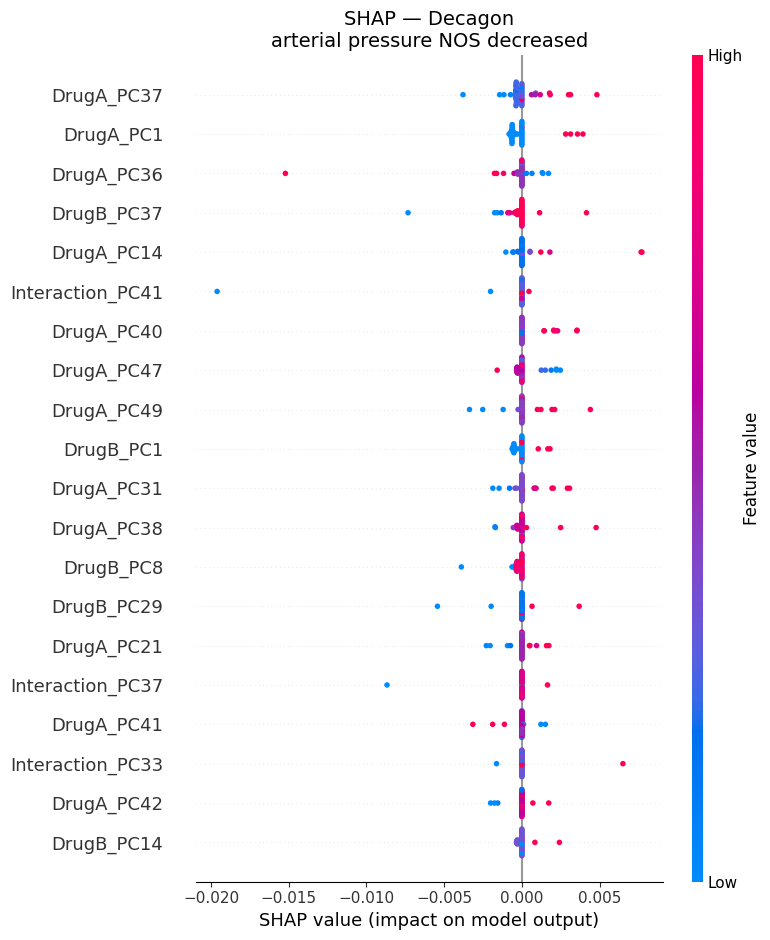

/tmp/ipykernel_10651/3225710808.py:189: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


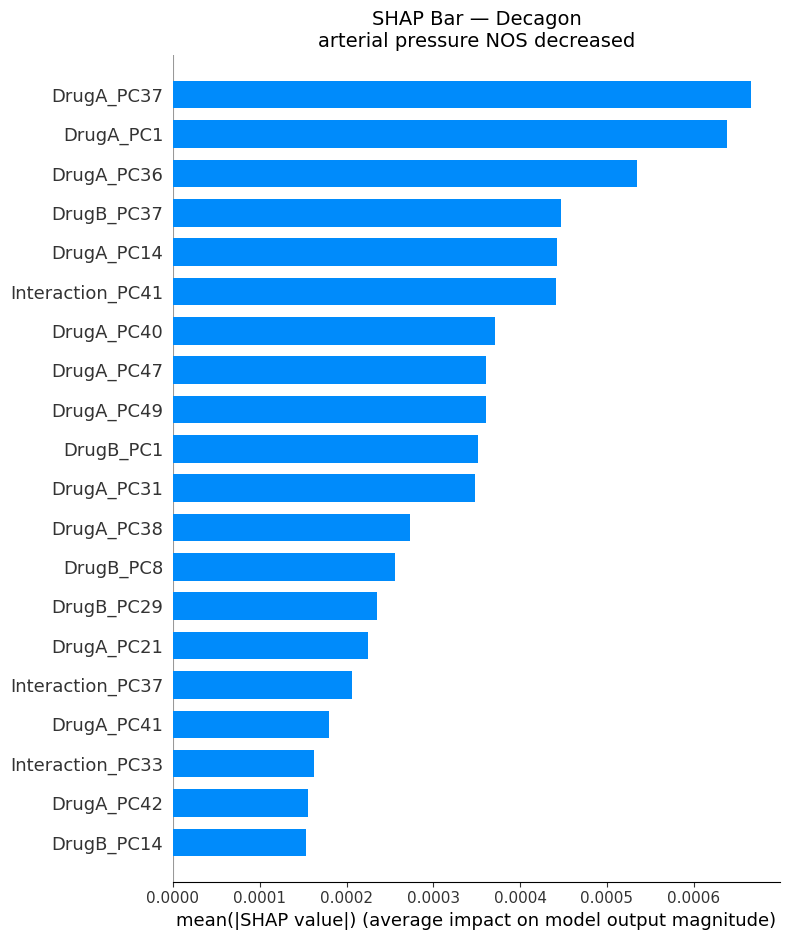


Completed: arterial pressure NOS decreased

Running SHAP for: dyshidrosis
SE index: 25 | Pairs: 553 | SMOTE: Yes
Test pairs: 165 pos, 165 neg
Prediction matrix: (645, 645)
Decagon AUROC: 0.6040  AUPRC: 0.6608
Training surrogate...
  Epoch 10: loss=0.0001
  Epoch 20: loss=0.0001
  Epoch 30: loss=0.0001
  Epoch 40: loss=0.0001
  Epoch 50: loss=0.0001
Surrogate correlation with Decagon: 0.7118
Calculating SHAP values (50 samples)...


  0%|          | 0/50 [00:00<?, ?it/s]

Done!

Feature groups:
  Drug A:      50.2%
  Drug B:      29.2%
  Interaction: 20.6%
  Top feature: DrugA_PC26 (0.0004)


/tmp/ipykernel_10651/3225710808.py:177: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


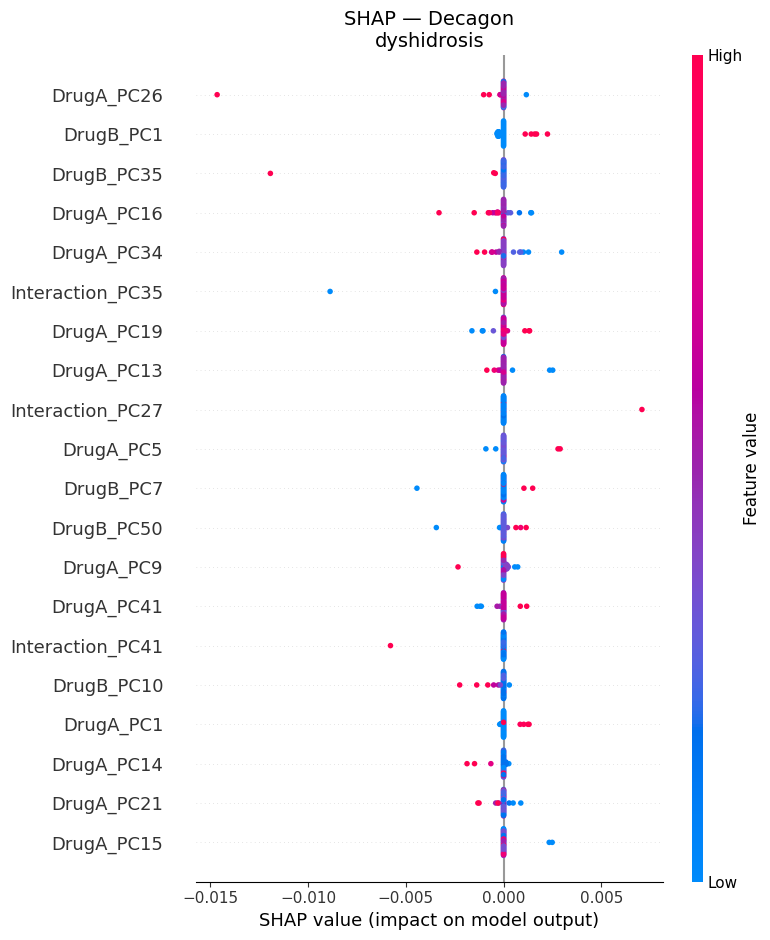

/tmp/ipykernel_10651/3225710808.py:189: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


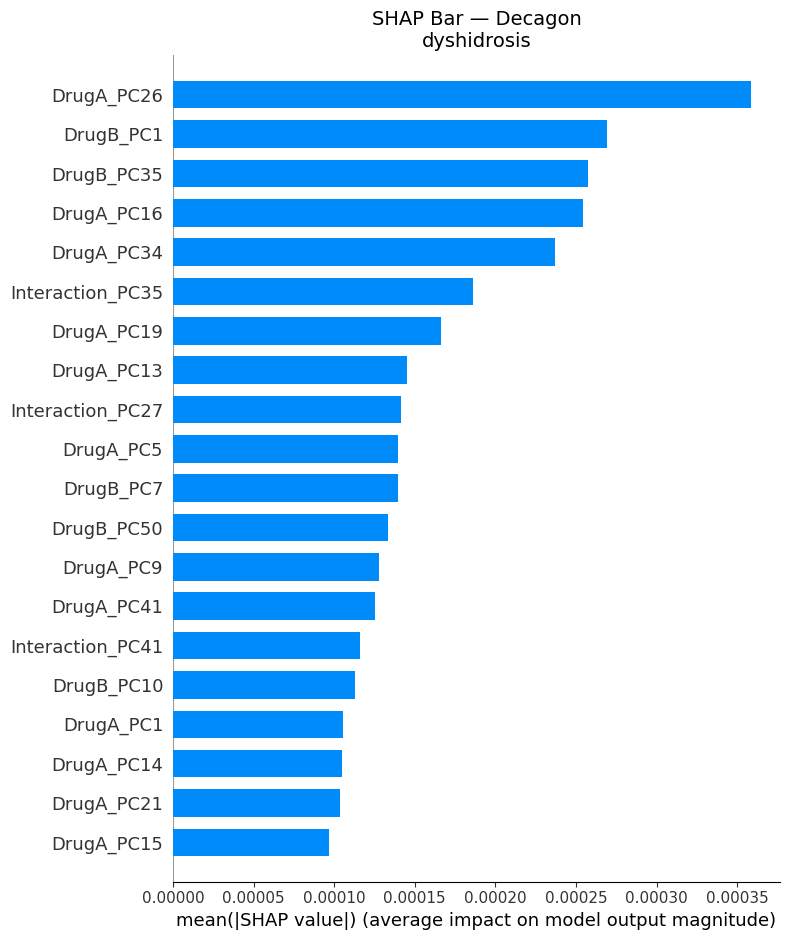


Completed: dyshidrosis

Running SHAP for: sarcoma
SE index: 49 | Pairs: 502 | SMOTE: Yes
Test pairs: 150 pos, 150 neg
Prediction matrix: (645, 645)
Decagon AUROC: 0.6111  AUPRC: 0.6110
Training surrogate...
  Epoch 10: loss=0.0001
  Epoch 20: loss=0.0001
  Epoch 30: loss=0.0001
  Epoch 40: loss=0.0001
  Epoch 50: loss=0.0001
Surrogate correlation with Decagon: 0.6853
Calculating SHAP values (50 samples)...


  0%|          | 0/50 [00:00<?, ?it/s]

Done!

Feature groups:
  Drug A:      36.9%
  Drug B:      43.7%
  Interaction: 19.4%
  Top feature: DrugB_PC5 (0.0003)


/tmp/ipykernel_10651/3225710808.py:177: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


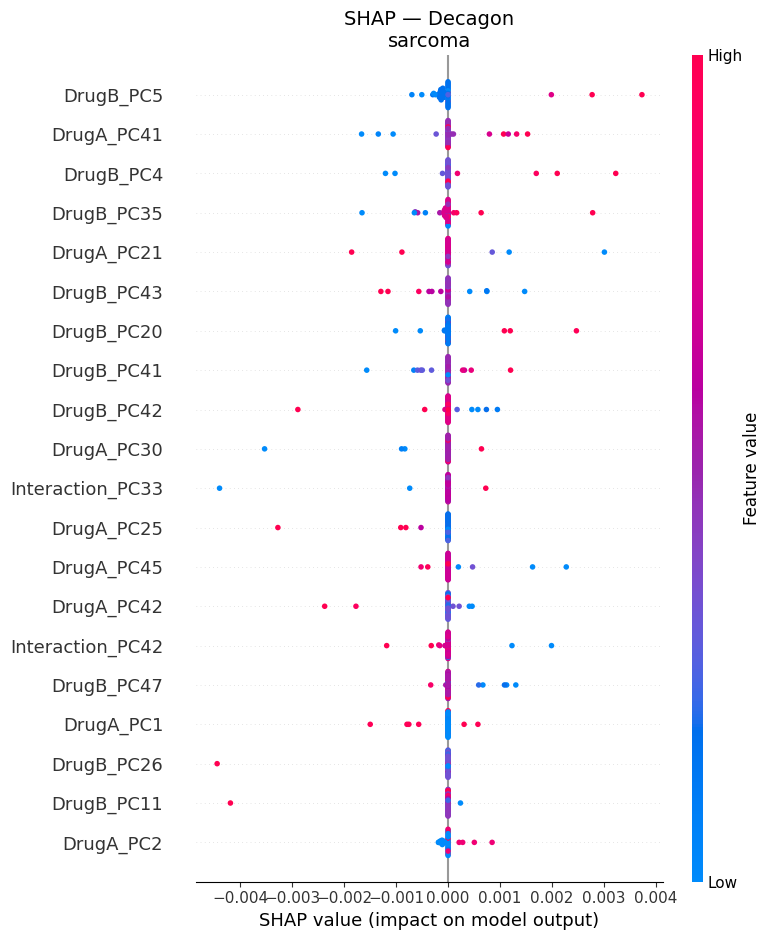

/tmp/ipykernel_10651/3225710808.py:189: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


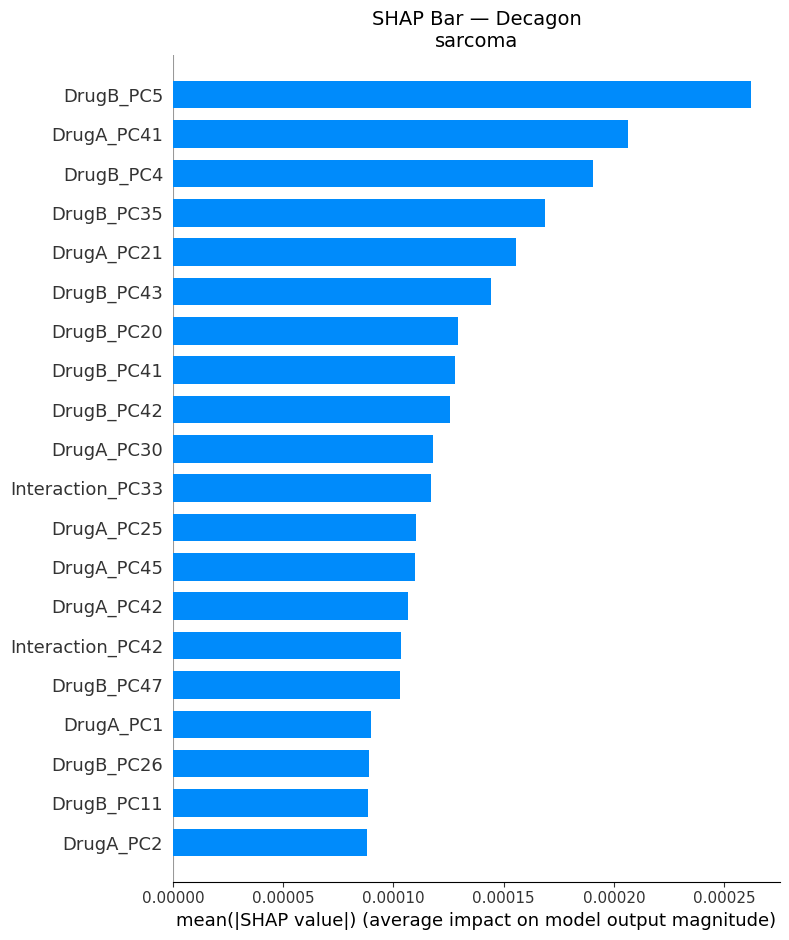


Completed: sarcoma

ALL SHAP ANALYSES COMPLETE!


In [ ]:
# Store results for comparison
all_shap_results = {}

for target_se_name_d in target_ses:
    print(f"\n{'='*65}")
    print(f"Running SHAP for: {target_se_name_d}")
    print(f"{'='*65}")

    # ── Get side effect index ─────────────────────────────
    target_se_d = combo_mixed[
        combo_mixed[se_name_col] == target_se_name_d
    ][se_col].iloc[0]

    # Find index in our all_se list
    if target_se_d not in all_se:
        print(f"WARNING: {target_se_name_d} not in all_se list!")
        continue

    se_idx_d      = all_se.index(target_se_d)
    n_pairs       = se_counts[target_se_d]
    smote_applied = n_pairs < 5000
    print(f"SE index: {se_idx_d} | Pairs: {n_pairs} | "
          f"SMOTE: {'Yes' if smote_applied else 'No'}")

    # ── Get test edges ────────────────────────────────────
    test_pos = minibatch.val_edges[(1,1)][se_idx_d]
    test_neg = minibatch.val_edges_false[(1,1)][se_idx_d]
    print(f"Test pairs: {len(test_pos)} pos, {len(test_neg)} neg")

    if len(test_pos) == 0 or len(test_neg) == 0:
        print("No test edges — skipping")
        continue

    # ── Build feature vectors ─────────────────────────────
    pos_d1 = np.array([u for u, v in test_pos])
    pos_d2 = np.array([v for u, v in test_pos])
    neg_d1 = np.array([u for u, v in test_neg])
    neg_d2 = np.array([v for u, v in test_neg])

    X_pos_d  = build_pair_features_shap(pos_d1, pos_d2, drug_features_d)
    X_neg_d  = build_pair_features_shap(neg_d1, neg_d2, drug_features_d)
    X_test_d = np.vstack([X_pos_d, X_neg_d])
    y_test_d = np.concatenate([
        np.ones(len(X_pos_d)),
        np.zeros(len(X_neg_d))
    ])

    scaler_d        = StandardScaler()
    X_test_scaled_d = scaler_d.fit_transform(X_test_d)

    # ── Get Decagon predictions ───────────────────────────
    feed_dict_shap = dict(feed_dict)
    feed_dict_shap.update({placeholders['dropout']: 0})
    feed_dict_shap.update({
        placeholders['batch_edge_type_idx']:
            minibatch.edge_type2idx[(1, 1, se_idx_d)]
    })
    feed_dict_shap.update({
        placeholders['batch_row_edge_type']: 1
    })
    feed_dict_shap.update({
        placeholders['batch_col_edge_type']: 1
    })

    rec_matrix = sess.run(
        opt.predictions, feed_dict=feed_dict_shap
    )
    print(f"Prediction matrix: {rec_matrix.shape}")

    decagon_scores = []
    for i in range(len(X_test_d)):
        if i < len(pos_d1):
            u, v = pos_d1[i], pos_d2[i]
        else:
            j    = i - len(pos_d1)
            u, v = neg_d1[j], neg_d2[j]
        decagon_scores.append(sigmoid(rec_matrix[u, v]))
    decagon_scores = np.array(decagon_scores)

    auroc_d = roc_auc_score(y_test_d, decagon_scores)
    auprc_d = average_precision_score(y_test_d, decagon_scores)
    print(f"Decagon AUROC: {auroc_d:.4f}  AUPRC: {auprc_d:.4f}")

    # ── Train surrogate MLP ───────────────────────────────
    class SurrogateMLP(nn.Module):
        def __init__(self, input_dim=150):
            super(SurrogateMLP, self).__init__()
            self.network = nn.Sequential(
                nn.Linear(input_dim, 256),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        def forward(self, x):
            return self.network(x).squeeze(-1)

    surrogate     = SurrogateMLP()
    optimizer_sur = torch.optim.Adam(
        surrogate.parameters(), lr=0.001
    )
    criterion_sur = nn.MSELoss()
    X_tr_sur      = torch.FloatTensor(X_test_scaled_d)
    y_tr_sur      = torch.FloatTensor(decagon_scores)

    print("Training surrogate...")
    for epoch in range(50):
        surrogate.train()
        pred_sur = surrogate(X_tr_sur)
        loss_sur = criterion_sur(pred_sur, y_tr_sur)
        optimizer_sur.zero_grad()
        loss_sur.backward()
        optimizer_sur.step()
        if (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1}: loss={loss_sur.item():.4f}")

    surrogate.eval()
    with torch.no_grad():
        sur_preds = surrogate(X_tr_sur).numpy()
    correlation = np.corrcoef(decagon_scores, sur_preds)[0,1]
    print(f"Surrogate correlation with Decagon: {correlation:.4f}")

    # ── SHAP analysis ─────────────────────────────────────
    def surrogate_predict(X):
        surrogate.eval()
        with torch.no_grad():
            return surrogate(torch.FloatTensor(X)).numpy()

    np.random.seed(42)
    bg_idx       = np.random.choice(
        len(X_test_scaled_d),
        min(100, len(X_test_scaled_d)),
        replace=False
    )
    background_d = X_test_scaled_d[bg_idx]
    explainer_d  = shap.KernelExplainer(
        surrogate_predict, background_d
    )

    n_explain     = min(50, len(X_test_scaled_d))
    explain_idx_d = np.random.choice(
        len(X_test_scaled_d), n_explain, replace=False
    )
    X_explain_d = X_test_scaled_d[explain_idx_d]
    y_explain_d = y_test_d[explain_idx_d]

    print(f"Calculating SHAP values ({n_explain} samples)...")
    shap_values_d = explainer_d.shap_values(X_explain_d)
    print("Done!")

    # ── Feature group importance ──────────────────────────
    mean_abs_d = np.abs(shap_values_d).mean(axis=0)
    drug_a_imp = mean_abs_d[:50].sum()
    drug_b_imp = mean_abs_d[50:100].sum()
    inter_imp  = mean_abs_d[100:].sum()
    total_imp  = drug_a_imp + drug_b_imp + inter_imp

    top_idx_d  = np.argsort(mean_abs_d)[::-1][0]
    top_feat   = feature_names_d[top_idx_d]
    top_imp    = mean_abs_d[top_idx_d]

    print(f"\nFeature groups:")
    print(f"  Drug A:      {drug_a_imp/total_imp:.1%}")
    print(f"  Drug B:      {drug_b_imp/total_imp:.1%}")
    print(f"  Interaction: {inter_imp/total_imp:.1%}")
    print(f"  Top feature: {top_feat} ({top_imp:.4f})")

    # ── Save plots ────────────────────────────────────────
    safe_name = target_se_name_d.replace(' ', '_').replace('/', '_')

    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_d, X_explain_d,
        feature_names=feature_names_d,
        max_display=20, show=False
    )
    plt.title(f'SHAP — Decagon\n{target_se_name_d}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'shap_decagon_{safe_name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_d, X_explain_d,
        feature_names=feature_names_d,
        plot_type='bar', max_display=20, show=False
    )
    plt.title(f'SHAP Bar — Decagon\n{target_se_name_d}',
              fontsize=14)
    plt.tight_layout()
    plt.savefig(f'shap_bar_decagon_{safe_name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Store results ─────────────────────────────────────
    all_shap_results[target_se_name_d] = {
        'auroc':       auroc_d,
        'auprc':       auprc_d,
        'drug_a_pct':  drug_a_imp/total_imp,
        'drug_b_pct':  drug_b_imp/total_imp,
        'inter_pct':   inter_imp/total_imp,
        'top_feature': top_feat,
        'top_imp':     top_imp,
        'n_pairs':     n_pairs,
        'smote':       smote_applied,
        'correlation': correlation,
        'shap_values': shap_values_d,
    }
    print(f"\nCompleted: {target_se_name_d}")

print("\n" + "="*65)
print("ALL SHAP ANALYSES COMPLETE!")
print("="*65)

In [ ]:
print("\n" + "="*75)
print("DECAGON SHAP COMPARISON ACROSS THREE SIDE EFFECTS")
print("="*75)
print(f"{'Side Effect':<35} {'Pairs':>6} {'SMOTE':>6} "
      f"{'Drug A':>8} {'Drug B':>8} {'Inter':>8} {'Top Feature':>15}")
print("-"*75)

for se_name, results in all_shap_results.items():
    print(f"{se_name:<35} "
          f"{results['n_pairs']:>6} "
          f"{'Yes' if results['smote'] else 'No':>6} "
          f"{results['drug_a_pct']:>7.1%} "
          f"{results['drug_b_pct']:>8.1%} "
          f"{results['inter_pct']:>8.1%} "
          f"{results['top_feature']:>15}")

print("\n" + "="*75)
print("MLP SHAP RESULTS (for comparison):")
print("="*75)
print(f"{'Fracture nonunion (MLP)':<35} {'600':>6} {'Yes':>6} "
      f"{'52.0%':>8} {'40.4%':>8} {'7.6%':>8} {'DrugA_PC1':>15}")
print(f"{'Ejac. Premature (MLP)':<35} {'700':>6} {'Yes':>6} "
      f"{'58.0%':>8} {'35.5%':>8} {'6.5%':>8} {'DrugA_PC1':>15}")

print("\n" + "="*75)
print("PERFORMANCE COMPARISON:")
print("="*75)
print(f"{'Side Effect':<35} {'AUROC':>8} {'AUPRC':>8} "
      f"{'Surrogate R':>12}")
print("-"*75)
for se_name, results in all_shap_results.items():
    print(f"{se_name:<35} "
          f"{results['auroc']:>8.4f} "
          f"{results['auprc']:>8.4f} "
          f"{results['correlation']:>12.4f}")



DECAGON SHAP COMPARISON ACROSS THREE SIDE EFFECTS
Side Effect                          Pairs  SMOTE   Drug A   Drug B    Inter     Top Feature
---------------------------------------------------------------------------
arterial pressure NOS decreased      28568     No   60.1%    26.9%    13.0%      DrugA_PC37
dyshidrosis                            553    Yes   50.2%    29.2%    20.6%      DrugA_PC26
sarcoma                                502    Yes   36.9%    43.7%    19.4%       DrugB_PC5

MLP SHAP RESULTS (for comparison):
Fracture nonunion (MLP)                600    Yes    52.0%    40.4%     7.6%       DrugA_PC1
Ejac. Premature (MLP)                  700    Yes    58.0%    35.5%     6.5%       DrugA_PC1

PERFORMANCE COMPARISON:
Side Effect                            AUROC    AUPRC  Surrogate R
---------------------------------------------------------------------------
arterial pressure NOS decreased       0.8171   0.7378       0.4326
dyshidrosis                           0.6040   

In [ ]:
import os
save_dir = '/content/drive/MyDrive/drug_drug_research'
print(os.listdir(save_dir))

['decagon_fixed', 'shap_results', 'models', 'plots', 'ppi_adj_filtered.npz', 'drug_prot_adj.npz', 'decagon_setup.pkl', 'decagon_shap_results.pkl']
